# Week 3: YOLOv8 알약 객체 탐지 및 OpenCV 시각화
데이터 다운로드 → 학습 → 평가 → OpenCV 시각화 → 결과 압축을 순서대로 수행합니다.

In [2]:
!pip -q install 'ultralytics>=8.3,<9' 'opencv-python-headless>=4.10,<5'
import json, random, shutil
from pathlib import Path
import cv2, matplotlib.pyplot as plt, torch, ultralytics
from ultralytics import YOLO
SEED = 42
random.seed(SEED); torch.manual_seed(SEED)
ROOT = Path('/content/week3')
OUTPUT_DIR, RUNS_DIR = ROOT / 'outputs', ROOT / 'runs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Ultralytics:', ultralytics.__version__)
print('PyTorch:', torch.__version__)
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 19.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.103
PyTorch: 2.11.0+cu128
GPU: Tesla T4


## 1. 설정
Medical Pills는 115장(학습 92, 검증 23)의 단일 `pill` 클래스 데이터셋입니다. 처음 학습할 때 자동 다운로드됩니다.

In [3]:
MODEL_NAME, DATA_YAML = 'yolov8n.pt', 'medical-pills.yaml'
EPOCHS, IMAGE_SIZE, BATCH_SIZE = 30, 640, 16
print({'model': MODEL_NAME, 'data': DATA_YAML, 'epochs': EPOCHS, 'imgsz': IMAGE_SIZE, 'batch': BATCH_SIZE, 'seed': SEED})

{'model': 'yolov8n.pt', 'data': 'medical-pills.yaml', 'epochs': 30, 'imgsz': 640, 'batch': 16, 'seed': 42}


## 2. YOLOv8n 전이학습
COCO 사전학습 가중치에서 시작해 `pill` 클래스에 맞게 미세조정합니다.

In [4]:
model = YOLO(MODEL_NAME)
model.train(data=DATA_YAML, epochs=EPOCHS, imgsz=IMAGE_SIZE, batch=BATCH_SIZE, seed=SEED, deterministic=True, project=str(RUNS_DIR), name='medical_pills_yolov8n', exist_ok=True, plots=True)
RUN_DIR = Path(model.trainer.save_dir)
BEST_WEIGHT = RUN_DIR / 'weights' / 'best.pt'
print('best weight:', BEST_WEIGHT, BEST_WEIGHT.exists())

Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=medical-pills.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=medical_pills_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

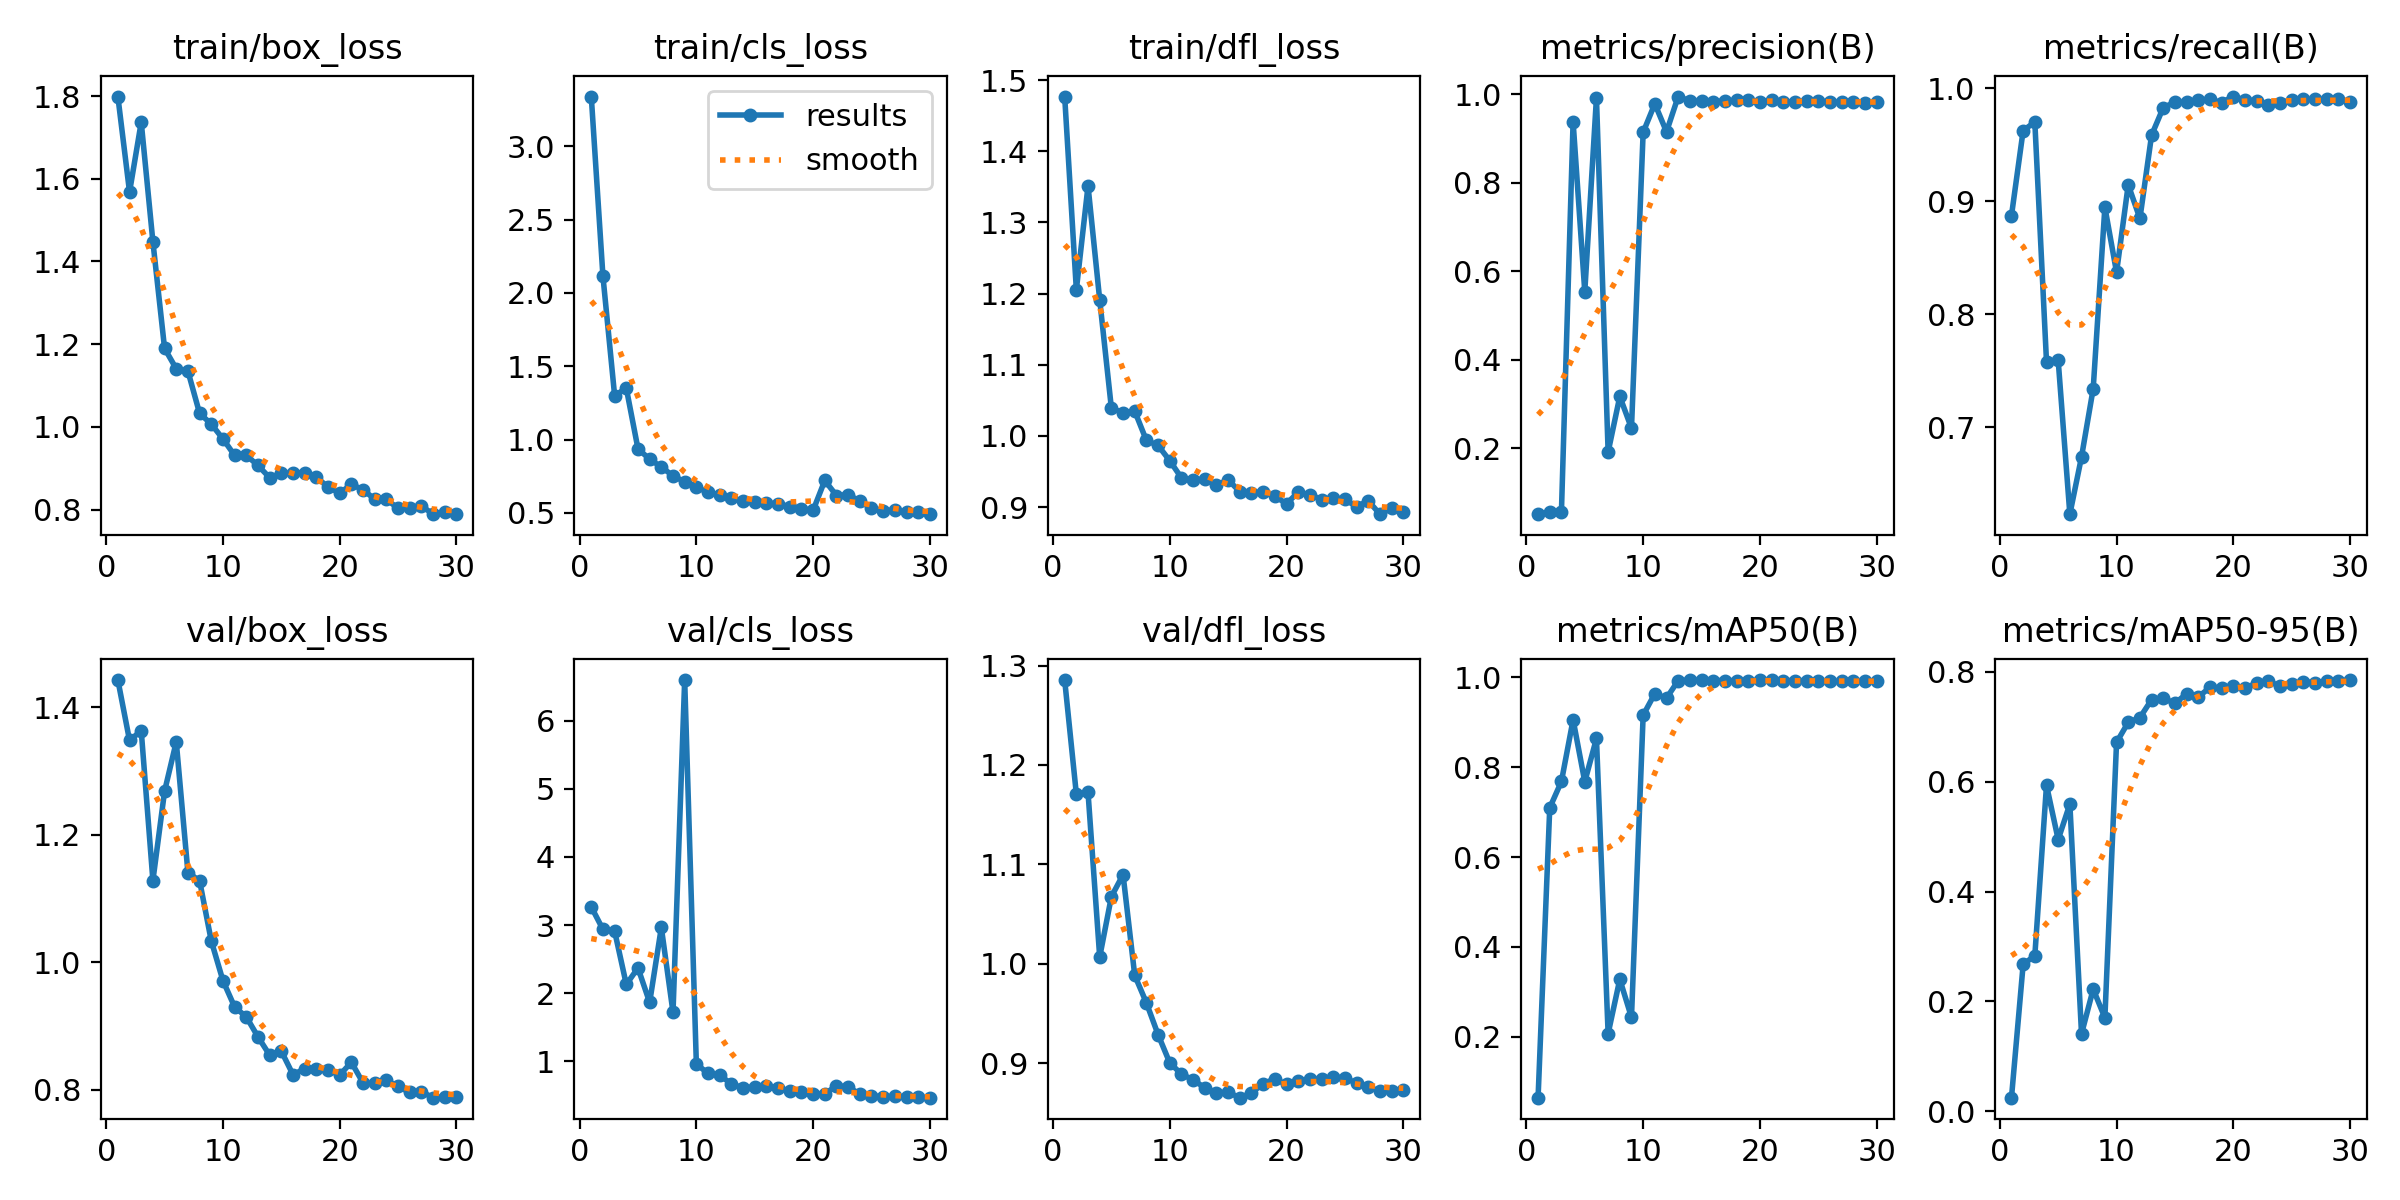

In [5]:
from IPython.display import display
from PIL import Image

display(Image.open(RUN_DIR / 'results.png'))


## 3. 검증 지표 저장
검증 세트에서 Precision, Recall, mAP50, mAP50-95를 계산합니다.

In [6]:
best_model = YOLO(str(BEST_WEIGHT))
validation = best_model.val(data=DATA_YAML, imgsz=IMAGE_SIZE, split='val', project=str(RUNS_DIR), name='validation', exist_ok=True, plots=True)
metrics = {'precision': round(float(validation.box.mp), 6), 'recall': round(float(validation.box.mr), 6), 'mAP50': round(float(validation.box.map50), 6), 'mAP50-95': round(float(validation.box.map), 6), 'model': MODEL_NAME, 'epochs': EPOCHS, 'image_size': IMAGE_SIZE, 'batch_size': BATCH_SIZE, 'seed': SEED, 'ultralytics_version': ultralytics.__version__}
(OUTPUT_DIR / 'metrics.json').write_text(json.dumps(metrics, ensure_ascii=False, indent=2), encoding='utf-8')
print(json.dumps(metrics, ensure_ascii=False, indent=2))
for filename in ['results.png', 'PR_curve.png', 'confusion_matrix.png']:
    source = RUN_DIR / filename
    if source.exists(): shutil.copy2(source, OUTPUT_DIR / filename)

Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2237.5±654.1 MB/s, size: 74.8 KB)
val: Scanning /content/datasets/medical-pills/labels/val.cache... 23 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 23/23 9.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.8it/s 1.1s
                   all         23        399      0.983      0.988      0.991      0.785
Speed: 5.2ms preprocess, 15.4ms inference, 0.0ms loss, 3.5ms postprocess per image
Results saved to /content/week3/runs/validation
{
  "precision": 0.982547,
  "recall": 0.987662,
  "mAP50": 0.990788,
  "mAP50-95": 0.784536,
  "model": "yolov8n.pt",
  "epochs": 30,
  "image_size": 640,
  "batch_size": 16,
  "seed": 42,
  "ultralytics_version": "8.4.103"
}


## 4. OpenCV 시각화
`result.plot()` 대신 좌표와 신뢰도를 꺼내 OpenCV 함수로 직접 그립니다.

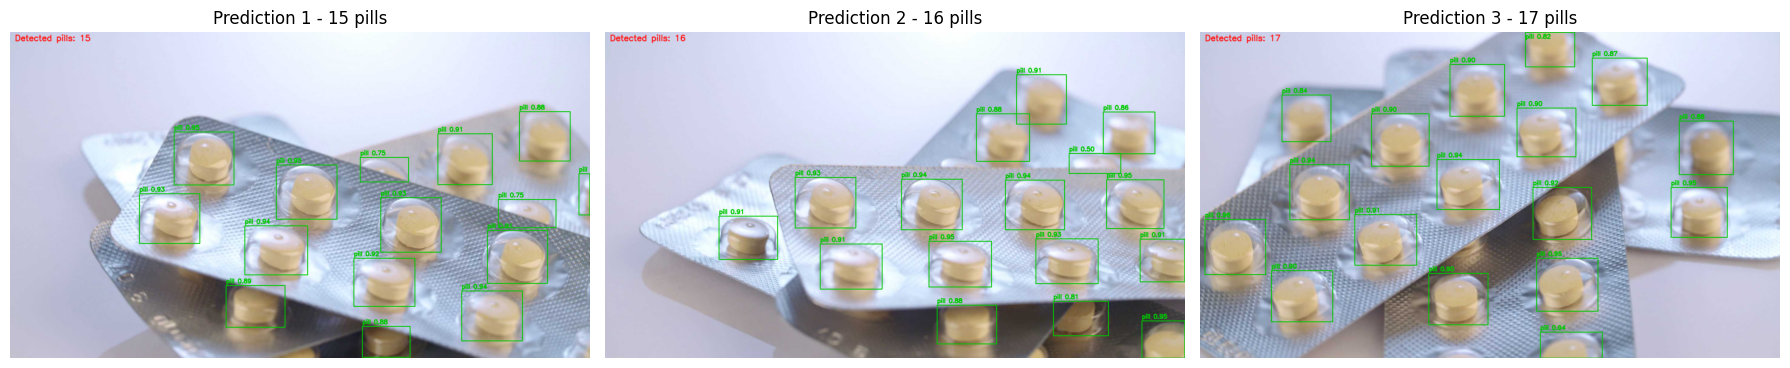

In [7]:
def find_validation_images():
    candidates = [Path('/content/datasets/medical-pills/images/val'), Path('/content/medical-pills/images/val'), Path.home() / 'datasets/medical-pills/images/val']
    for directory in candidates:
        images = sorted([*directory.glob('*.jpg'), *directory.glob('*.jpeg'), *directory.glob('*.png')])
        if images: return images
    return [p for p in sorted(Path('/content').glob('**/medical-pills/images/val/*')) if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}]

def draw_detections(image_path, result, output_path):
    image = cv2.imread(str(image_path))
    if image is None: raise FileNotFoundError(image_path)
    count = 0
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().tolist())
        conf, cls = float(box.conf[0].cpu()), int(box.cls[0].cpu())
        label = f'{result.names[cls]} {conf:.2f}'
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 200, 0), 2)
        cv2.putText(image, label, (x1, max(24, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 200, 0), 2, cv2.LINE_AA)
        count += 1
    cv2.putText(image, f'Detected pills: {count}', (16, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (30, 30, 255), 2, cv2.LINE_AA)
    cv2.imwrite(str(output_path), image)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB), count

validation_images = find_validation_images()
if len(validation_images) < 3: raise RuntimeError(f'검증 이미지를 찾지 못했습니다: {len(validation_images)}장')
sample_images = random.Random(SEED).sample(validation_images, 3)
predictions = best_model.predict(sample_images, imgsz=IMAGE_SIZE, conf=0.25, verbose=False)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for index, (image_path, prediction) in enumerate(zip(sample_images, predictions), start=1):
    rgb, count = draw_detections(image_path, prediction, OUTPUT_DIR / f'prediction_{index:02d}.jpg')
    axes[index - 1].imshow(rgb); axes[index - 1].set_title(f'Prediction {index} - {count} pills'); axes[index - 1].axis('off')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'predictions_grid.png', dpi=150, bbox_inches='tight'); plt.show()

## 5. 데이터 원본과 Ground Truth 확인
학습에 사용된 원본 이미지와 YOLO 라벨을 직접 읽어 빨간색 Ground Truth bbox를 표시합니다. 데이터 통계도 파일을 실제로 세어 계산합니다.

Dataset root: /content/datasets/medical-pills
{'split': 'train', 'images': 92, 'label_files': 92, 'objects': 1623, 'objects_per_image': 17.641304347826086}
{'split': 'val', 'images': 23, 'label_files': 23, 'objects': 399, 'objects_per_image': 17.347826086956523}
{'split': 'total', 'images': 115, 'label_files': 115, 'objects': 2022, 'objects_per_image': 17.582608695652173}


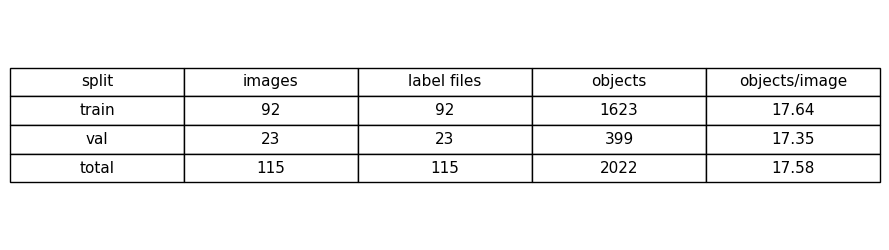

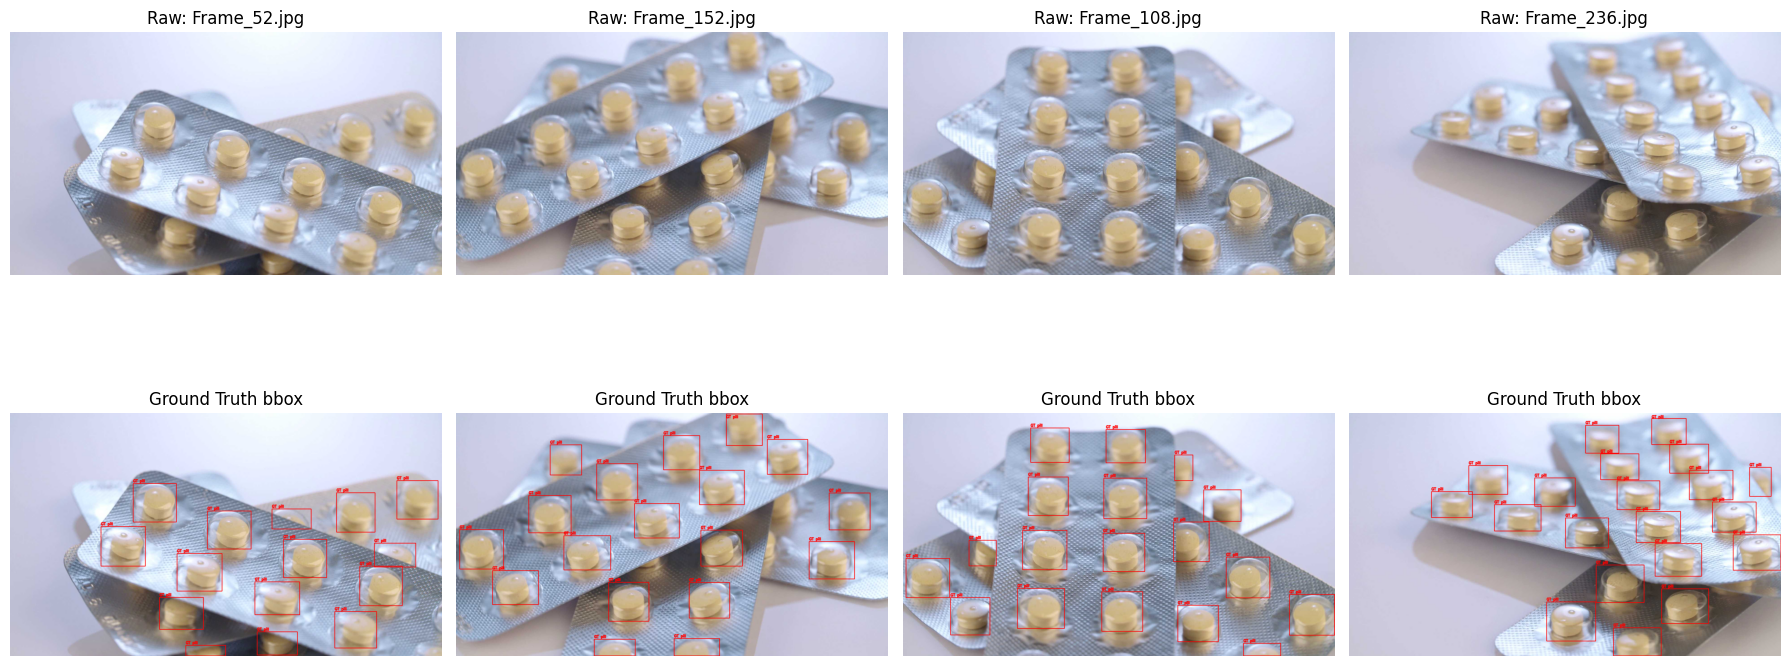

In [8]:
DATASET_ROOT = validation_images[0].parent.parent.parent
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png'}

def split_statistics(split):
    image_dir = DATASET_ROOT / 'images' / split
    label_dir = DATASET_ROOT / 'labels' / split
    images = sorted(p for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS)
    labels = sorted(label_dir.glob('*.txt'))
    objects = sum(sum(1 for line in path.read_text(encoding='utf-8').splitlines() if line.strip()) for path in labels)
    return {'split': split, 'images': len(images), 'label_files': len(labels), 'objects': objects, 'objects_per_image': objects / len(images)}, images

train_stats, train_images = split_statistics('train')
val_stats, val_images = split_statistics('val')
total_stats = {'split': 'total', 'images': train_stats['images'] + val_stats['images'], 'label_files': train_stats['label_files'] + val_stats['label_files'], 'objects': train_stats['objects'] + val_stats['objects']}
total_stats['objects_per_image'] = total_stats['objects'] / total_stats['images']
statistics = [train_stats, val_stats, total_stats]
print('Dataset root:', DATASET_ROOT)
for row in statistics: print(row)

fig, ax = plt.subplots(figsize=(9, 2.6))
ax.axis('off')
table_data = [[row['split'], row['images'], row['label_files'], row['objects'], f"{row['objects_per_image']:.2f}"] for row in statistics]
table = ax.table(cellText=table_data, colLabels=['split', 'images', 'label files', 'objects', 'objects/image'], cellLoc='center', loc='center')
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1, 1.5)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'dataset_statistics.png', dpi=180, bbox_inches='tight'); plt.show(); plt.close(fig)

def draw_ground_truth(image_path):
    image = cv2.imread(str(image_path))
    if image is None: raise FileNotFoundError(image_path)
    height, width = image.shape[:2]
    label_path = DATASET_ROOT / 'labels' / image_path.parent.name / f'{image_path.stem}.txt'
    if label_path.exists():
        for line in label_path.read_text(encoding='utf-8').splitlines():
            if not line.strip(): continue
            class_id, xc, yc, box_w, box_h = map(float, line.split())
            x1 = max(0, int((xc - box_w / 2) * width)); y1 = max(0, int((yc - box_h / 2) * height))
            x2 = min(width - 1, int((xc + box_w / 2) * width)); y2 = min(height - 1, int((yc + box_h / 2) * height))
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 0, 255), 2)
            cv2.putText(image, 'GT pill', (x1, max(22, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 255), 2, cv2.LINE_AA)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

data_samples = random.Random(SEED).sample(train_images, 4)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for col, image_path in enumerate(data_samples):
    raw = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    axes[0, col].imshow(raw); axes[0, col].set_title(f'Raw: {image_path.name}'); axes[0, col].axis('off')
    axes[1, col].imshow(draw_ground_truth(image_path)); axes[1, col].set_title('Ground Truth bbox'); axes[1, col].axis('off')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'dataset_samples_gt.png', dpi=150, bbox_inches='tight'); plt.show(); plt.close(fig)

## 6. 평가 지표 표와 학습 결과 시각화
네 지표를 같은 0~1 축에서 비교하고, 저장된 학습 곡선과 Confusion Matrix를 함께 확인합니다.

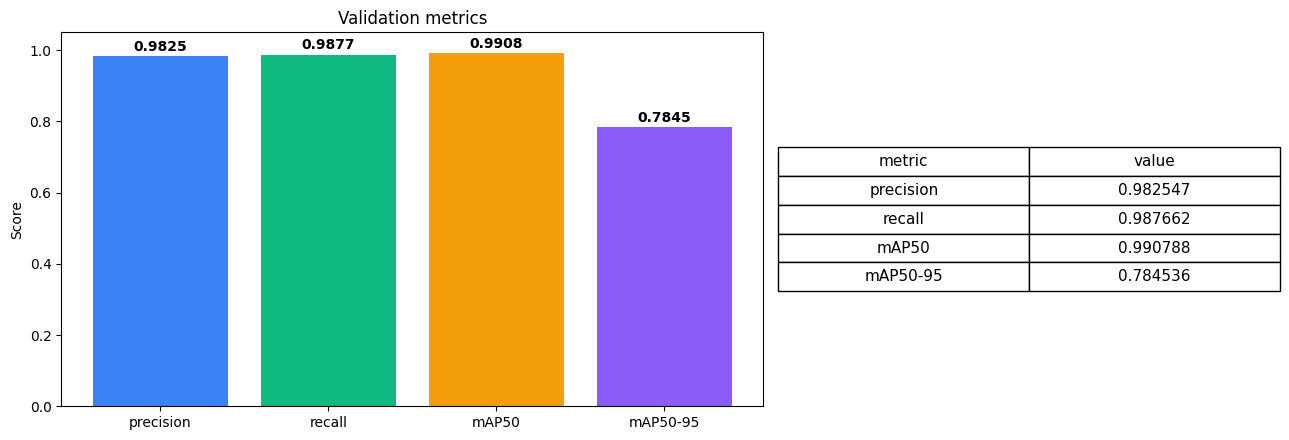

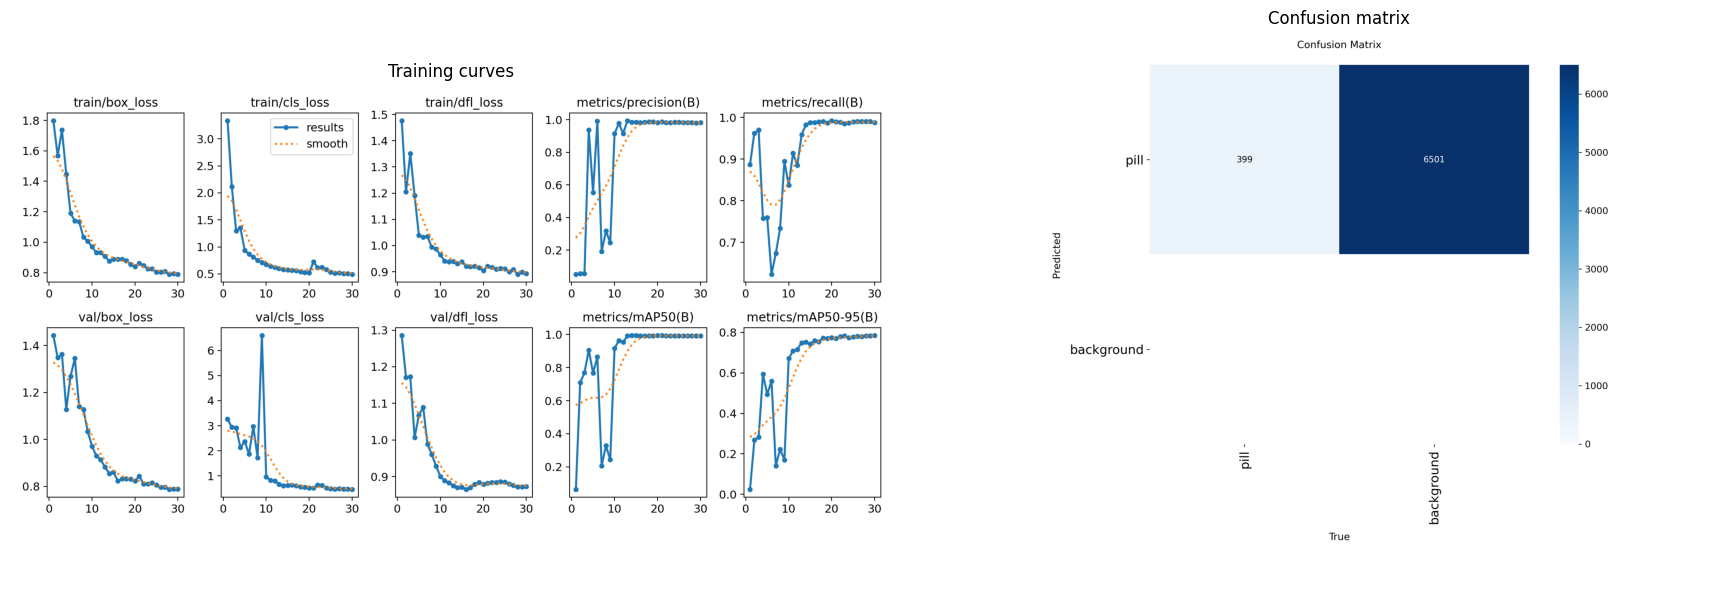

In [9]:
metrics_data = json.loads((OUTPUT_DIR / 'metrics.json').read_text(encoding='utf-8'))
metric_names = ['precision', 'recall', 'mAP50', 'mAP50-95']
metric_values = [metrics_data[name] for name in metric_names]

fig, (ax_bar, ax_table) = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={'width_ratios': [1.4, 1]})
bars = ax_bar.bar(metric_names, metric_values, color=['#3B82F6', '#10B981', '#F59E0B', '#8B5CF6'])
ax_bar.set_ylim(0, 1.05); ax_bar.set_ylabel('Score'); ax_bar.set_title('Validation metrics')
for bar, value in zip(bars, metric_values): ax_bar.text(bar.get_x() + bar.get_width() / 2, value + 0.015, f'{value:.4f}', ha='center', fontweight='bold')
ax_table.axis('off')
metric_table = ax_table.table(cellText=[[name, f'{value:.6f}'] for name, value in zip(metric_names, metric_values)], colLabels=['metric', 'value'], cellLoc='center', loc='center')
metric_table.auto_set_font_size(False); metric_table.set_fontsize(11); metric_table.scale(1, 1.6)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'metrics_summary.png', dpi=180, bbox_inches='tight'); plt.show(); plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].imshow(plt.imread(OUTPUT_DIR / 'results.png')); axes[0].set_title('Training curves'); axes[0].axis('off')
axes[1].imshow(plt.imread(OUTPUT_DIR / 'confusion_matrix.png')); axes[1].set_title('Confusion matrix'); axes[1].axis('off')
plt.tight_layout(); plt.show(); plt.close(fig)

## 7. Confidence threshold 비교
같은 이미지와 같은 `conf=0.25` 추론 결과에서 confidence가 0.25, 0.50, 0.75 이상인 박스만 남겨 검출 수 변화를 비교합니다. 이는 모델 재학습이나 성능 개선 실험이 아니라 후처리 기준 분석입니다.

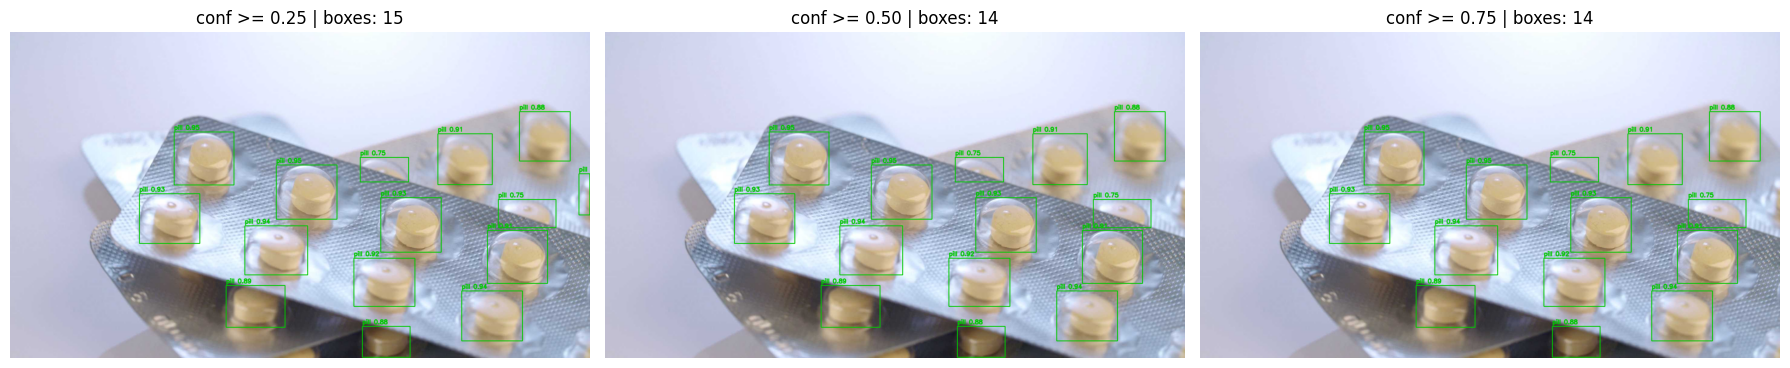

In [10]:
def draw_filtered_detections(image_path, result, threshold):
    image = cv2.imread(str(image_path))
    if image is None: raise FileNotFoundError(image_path)
    count = 0
    for box in result.boxes:
        confidence = float(box.conf[0].cpu())
        if confidence < threshold: continue
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().tolist())
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 200, 0), 2)
        cv2.putText(image, f'pill {confidence:.2f}', (x1, max(24, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 200, 0), 2, cv2.LINE_AA)
        count += 1
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB), count

lowest_confidences = [min((float(box.conf[0].cpu()) for box in prediction.boxes), default=1.0) for prediction in predictions]
comparison_index = lowest_confidences.index(min(lowest_confidences))
thresholds = [0.25, 0.50, 0.75]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, threshold in zip(axes, thresholds):
    rgb, count = draw_filtered_detections(sample_images[comparison_index], predictions[comparison_index], threshold)
    ax.imshow(rgb); ax.set_title(f'conf >= {threshold:.2f} | boxes: {count}'); ax.axis('off')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'confidence_threshold_comparison.png', dpi=150, bbox_inches='tight'); plt.show(); plt.close(fig)

## 8. Detection을 Counting으로 확장
검증 이미지별 Ground Truth bbox 수와 예측 bbox 수를 비교해 Count MAE와 Exact-match rate를 계산합니다. 이 값이 있어야 단순한 박스 개수 표시를 넘어 counting 성능을 말할 수 있습니다.

{
  "confidence_threshold": 0.25,
  "images": 23,
  "count_mae": 0.521739,
  "exact_match_rate": 0.565217
}


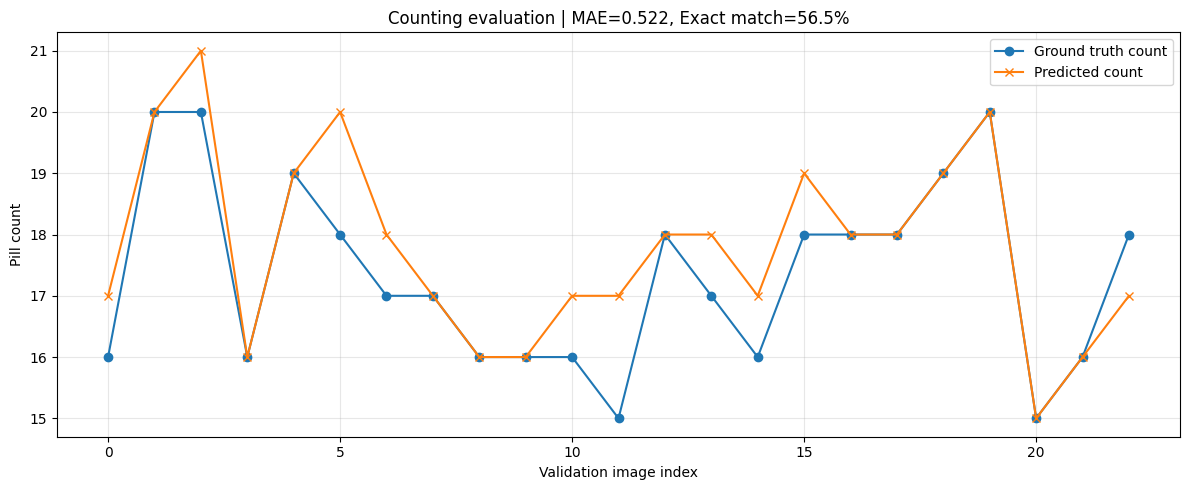

In [11]:
all_val_predictions = best_model.predict(validation_images, imgsz=IMAGE_SIZE, conf=0.25, verbose=False)
count_rows = []
for image_path, prediction in zip(validation_images, all_val_predictions):
    label_path = DATASET_ROOT / 'labels' / 'val' / f'{image_path.stem}.txt'
    gt_count = sum(1 for line in label_path.read_text(encoding='utf-8').splitlines() if line.strip()) if label_path.exists() else 0
    pred_count = len(prediction.boxes)
    count_rows.append({'image': image_path.name, 'ground_truth': gt_count, 'predicted': pred_count, 'absolute_error': abs(pred_count - gt_count)})
count_mae = sum(row['absolute_error'] for row in count_rows) / len(count_rows)
exact_match_rate = sum(row['absolute_error'] == 0 for row in count_rows) / len(count_rows)
counting_metrics = {'confidence_threshold': 0.25, 'images': len(count_rows), 'count_mae': round(count_mae, 6), 'exact_match_rate': round(exact_match_rate, 6)}
(OUTPUT_DIR / 'counting_metrics.json').write_text(json.dumps(counting_metrics, ensure_ascii=False, indent=2), encoding='utf-8')
print(json.dumps(counting_metrics, ensure_ascii=False, indent=2))

fig, ax = plt.subplots(figsize=(12, 5))
x = list(range(len(count_rows)))
ax.plot(x, [row['ground_truth'] for row in count_rows], marker='o', label='Ground truth count')
ax.plot(x, [row['predicted'] for row in count_rows], marker='x', label='Predicted count')
ax.set_xlabel('Validation image index'); ax.set_ylabel('Pill count'); ax.set_title(f'Counting evaluation | MAE={count_mae:.3f}, Exact match={exact_match_rate:.1%}')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'counting_evaluation.png', dpi=180, bbox_inches='tight'); plt.show(); plt.close(fig)

## 9. 결과 압축 및 다운로드

In [12]:
shutil.copy2(BEST_WEIGHT, OUTPUT_DIR / 'best.pt')
archive_path = shutil.make_archive('/content/week3_artifacts', 'zip', ROOT, 'outputs')
for path in sorted(OUTPUT_DIR.iterdir()): print('-', path.name, f'({path.stat().st_size / 1024:.1f} KB)')
from google.colab import files
files.download(archive_path)

- best.pt (6077.3 KB)
- confidence_threshold_comparison.png (436.7 KB)
- confusion_matrix.png (95.0 KB)
- counting_evaluation.png (137.2 KB)
- counting_metrics.json (0.1 KB)
- dataset_samples_gt.png (2163.5 KB)
- dataset_statistics.png (30.7 KB)
- metrics.json (0.2 KB)
- metrics_summary.png (68.9 KB)
- prediction_01.jpg (228.9 KB)
- prediction_02.jpg (220.0 KB)
- prediction_03.jpg (269.9 KB)
- predictions_grid.png (1207.3 KB)
- results.png (264.8 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>